In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
pd.set_option("Display.max_columns",None)
df=pd.read_csv("TelcoCustomerChurn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.shape

(7043, 21)

In [7]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [8]:
df.SeniorCitizen.unique()

array([0, 1], dtype=int64)

<Axes: xlabel='tenure', ylabel='Density'>

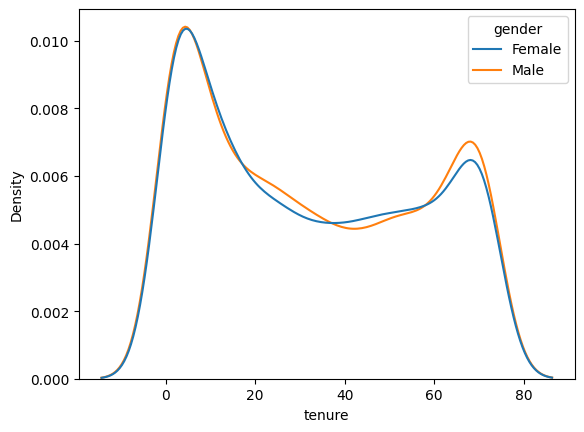

In [9]:
sns.kdeplot(data=df,x='tenure',hue='gender')

<Axes: xlabel='tenure', ylabel='Density'>

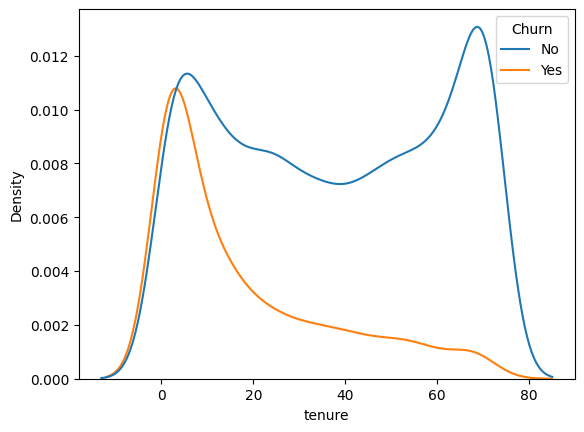

In [10]:
sns.kdeplot(data=df,x='tenure',hue='Churn')

In [11]:
df.PaperlessBilling.unique()

array(['Yes', 'No'], dtype=object)

<Axes: xlabel='InternetService', ylabel='count'>

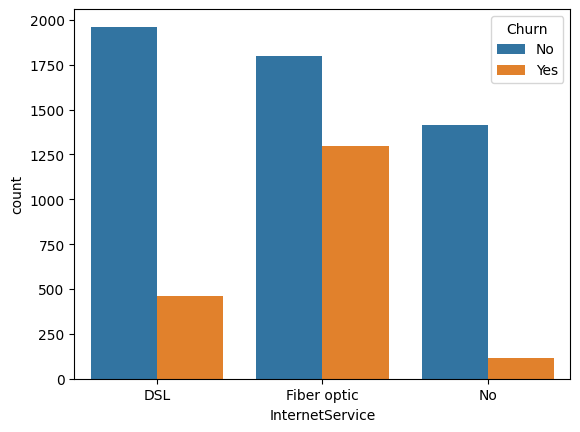

In [12]:
sns.countplot(data=df,x='InternetService',hue="Churn")

In [13]:
df.StreamingMovies.value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [14]:
df.StreamingTV.value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

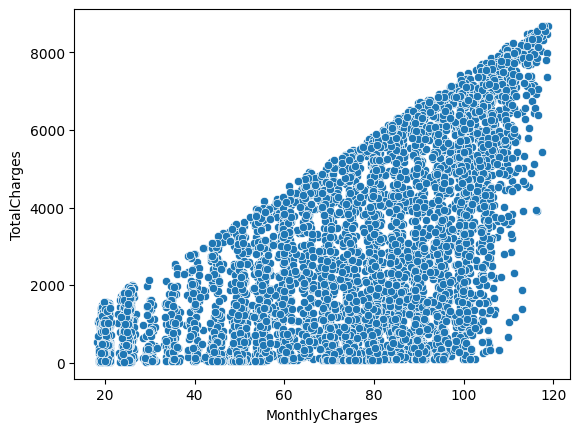

In [15]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
sns.scatterplot(data=df,x="MonthlyCharges",y="TotalCharges")

In [16]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["tenure","MonthlyCharges", "TotalCharges"]].dropna()

for i in range(X.shape[1]):
    print(X.columns[i], variance_inflation_factor(X.values, i))

tenure 6.332432315625668
MonthlyCharges 3.3610754122458344
TotalCharges 8.079180730673682


In [17]:
df[["tenure", "MonthlyCharges","TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


# Clean Data set for Model

In [19]:
df=pd.read_csv("TelcoCustomerChurn.csv")

In [20]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [21]:
df.sample(7)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3248,7779-LGOVN,Male,1,Yes,No,10,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.65,856.65,Yes
3938,6629-LADHQ,Female,0,No,No,2,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,50.95,123.05,No
5707,4537-DKTAL,Female,0,No,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.55,84.4,No
4473,2665-NPTGL,Female,1,Yes,No,26,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),98.10,2510.7,No
466,9076-AXYIK,Male,1,Yes,No,64,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Two year,No,Electronic check,102.10,6538.45,No
1382,4538-WNTMJ,Female,0,Yes,Yes,46,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,24.95,1165.9,No
4661,9415-ZNBSX,Female,0,Yes,Yes,70,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.00,6293.2,No


In [22]:
df.drop(columns=['customerID','TotalCharges'],inplace=True)

In [23]:
# df["SeniorCitizen"]=df["SeniorCitizen"].map(lambda x : "Yes" if x==1 else 'No')

In [24]:
df['MultipleLines']=df['MultipleLines'].replace({"No phone service":"No"})


In [25]:
lst=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV', 'StreamingMovies']

for i in lst:
    df[i]=df[i].replace({"No internet service":"No"})

In [26]:
df.PaperlessBilling.unique()

array(['Yes', 'No'], dtype=object)

In [27]:
df.sample(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
2337,Female,1,No,No,56,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),104.75,Yes
3969,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.95,No
972,Male,0,No,No,58,Yes,No,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Bank transfer (automatic),70.10,No
329,Female,1,No,No,17,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),82.65,No
12,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,No
4872,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),84.90,No
1324,Female,0,Yes,Yes,4,Yes,No,No,No,No,No,No,No,No,Month-to-month,No,Mailed check,20.35,Yes
3564,Male,0,No,No,63,Yes,Yes,Fiber optic,No,Yes,No,No,No,Yes,One year,No,Credit card (automatic),90.45,No
4719,Male,0,No,No,36,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.90,Yes
46,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,No,Mailed check,49.25,No


In [28]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
dtype: int64

In [29]:
df.to_csv("Clean_TelcoCustomerChurn.csv",index=False)